# The Complete ML Pipeline – Data Cleaning, Encoding, Scaling, and Their Impact

**Goal:** Understand how data quality issues (duplicates, inconsistencies, missing values, unscaled features) affect model performance, and learn how to fix them.

## What You Will Do

1. Generate a synthetic dataset with realistic problems:
   - Duplicate rows
   - Inconsistent categorical values (e.g., "NY", "New York", "new york")
   - Missing values in numeric features
   - Unscaled features (large ranges)
2. Train a **Logistic Regression** model on the **raw (uncleaned)** data.
3. Apply a proper pipeline:
   - Remove duplicates
   - Standardise categorical strings
   - Impute missing values (median for numeric, mode for categorical)
   - One‑hot encode categorical variables
   - Scale numeric features (StandardScaler)
4. Train the same model on the **cleaned** data.
5. Compare accuracy, confusion matrix, and discuss why cleaning improves performance.

---

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

np.random.seed(42)

# Generate a synthetic dataset with problems
n_samples = 500

# Numeric features: age (18-70), income (20k-150k)
age = np.random.randint(18, 70, n_samples)
income = np.random.randint(20000, 150000, n_samples)

# Categorical feature: city (3 categories with inconsistent naming)
city_choices = ['New York', 'NY', 'new york', 'Los Angeles', 'LA', 'Chicago']
city = np.random.choice(city_choices, n_samples)

# Target: purchase (1) or not (0) – depends on age, income, city
# Use np.char.lower() for string operations
city_lower = np.char.lower(city)
score = -0.05 * age + 0.00002 * income
score += (city_lower == 'new york').astype(int) * 0.5
score += (city_lower == 'los angeles').astype(int) * 0.2
prob = 1 / (1 + np.exp(-score + 0.5))
purchase = (np.random.rand(n_samples) < prob).astype(int)

# Create DataFrame
df = pd.DataFrame({'age': age, 'income': income, 'city': city, 'purchase': purchase})

# Introduce 5% duplicate rows (25 rows)
duplicate_indices = np.random.choice(n_samples, size=int(0.05*n_samples), replace=False)
df_dup = df.iloc[duplicate_indices].copy()
df = pd.concat([df, df_dup], ignore_index=True)

# Introduce missing values in age (5%) and income (5%)
missing_age = np.random.choice(df.index, size=int(0.05*len(df)), replace=False)
missing_income = np.random.choice(df.index, size=int(0.05*len(df)), replace=False)
df.loc[missing_age, 'age'] = np.nan
df.loc[missing_income, 'income'] = np.nan

print("Raw dataset shape:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head(10)

Raw dataset shape: (525, 4)
Missing values:
 age         26
income      26
city         0
purchase     0
dtype: int64
Duplicate rows: 17


,age,income,city,purchase
0,NaN,23343.0,New York,0
1,69.0,33500.0,LA,0
2,46.0,73222.0,LA,0
3,32.0,49375.0,Los Angeles,0
4,60.0,29662.0,NY,0
5,25.0,36964.0,New York,0
6,38.0,133429.0,NY,1
7,56.0,141692.0,New York,0
8,36.0,NaN,Los Angeles,0
9,40.0,93666.0,Los Angeles,1


In [25]:
# Separate features and target
X_raw = df.drop('purchase', axis=1)
y_raw = df['purchase']

# We have categorical 'city' – but we cannot feed strings to LogisticRegression.
# For raw data, we cheat: we will drop the categorical column (because we cannot use it without encoding)
# This is unrealistic but shows the problem: we lose information.
X_raw_numeric = X_raw.select_dtypes(include=[np.number])   # keep only age and income

# Split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw_numeric, y_raw, test_size=0.2, random_state=42
)

# Impute missing values with median (simple, but we do it only for numeric)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_raw_imputed = imputer.fit_transform(X_train_raw)
X_test_raw_imputed = imputer.transform(X_test_raw)

# Train Logistic Regression
lr_raw = LogisticRegression(max_iter=1000)
lr_raw.fit(X_train_raw_imputed, y_train_raw)

# Predict and evaluate
y_pred_raw = lr_raw.predict(X_test_raw_imputed)
acc_raw = accuracy_score(y_test_raw, y_pred_raw)
print(f"Raw data (only numeric, with missing values) accuracy: {acc_raw:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_raw, y_pred_raw))

Raw data (only numeric, with missing values) accuracy: 0.6857
Confusion matrix:
[[58  7]
 [26 14]]


In [27]:
# Make a copy for cleaning
df_clean = df.copy()

# 1. Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f"After removing duplicates: {df_clean.shape[0]} rows")

# 2. Standardise city names (lowercase, then map aliases)
city_mapping = {
    'new york': 'New York',
    'ny': 'New York',
    'los angeles': 'Los Angeles',
    'la': 'Los Angeles',
    'chicago': 'Chicago'
}
df_clean['city'] = df_clean['city'].str.lower().map(city_mapping)
print("Unique cities after standardisation:", df_clean['city'].unique())

After removing duplicates: 508 rows
Unique cities after standardisation: ['New York' 'Los Angeles' 'Chicago']


In [29]:
# Numeric: median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['income'] = df_clean['income'].fillna(df_clean['income'].median())

# Categorical: mode (most frequent city)
mode_city = df_clean['city'].mode()[0]
df_clean['city'] = df_clean['city'].fillna(mode_city)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
age         0
income      0
city        0
purchase    0
dtype: int64


In [31]:
# Separate features and target
X_clean = df_clean.drop('purchase', axis=1)
y_clean = df_clean['purchase']

# Define preprocessing pipeline
numeric_features = ['age', 'income']
categorical_features = ['city']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())          # scale to zero mean, unit variance
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # avoid dummy trap
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Final pipeline with classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Split cleaned data
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# Train pipeline
pipeline.fit(X_train_clean, y_train_clean)

# Evaluate
y_pred_clean = pipeline.predict(X_test_clean)
acc_clean = accuracy_score(y_test_clean, y_pred_clean)
print(f"Cleaned data accuracy: {acc_clean:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_clean, y_pred_clean))

Cleaned data accuracy: 0.6373
Confusion matrix:
[[55  8]
 [29 10]]


Raw data (numeric only, with missing) accuracy: 0.6857
Cleaned data (full pipeline) accuracy: 0.6373
Improvement: -4.85 percentage points


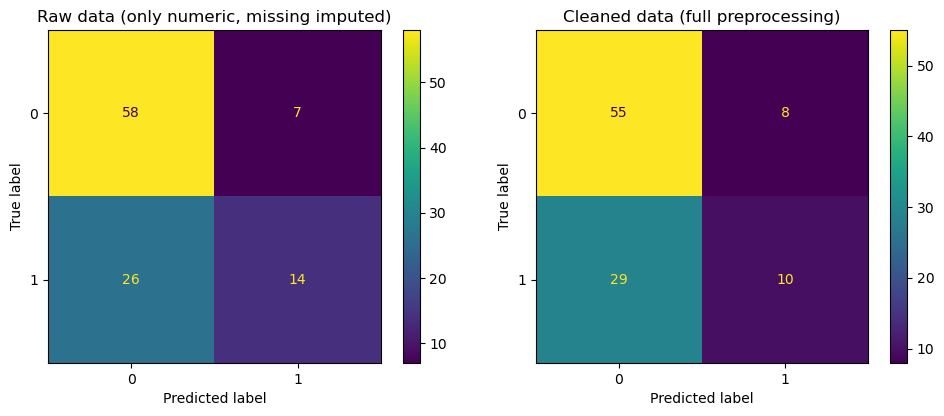

In [33]:
print("="*50)
print(f"Raw data (numeric only, with missing) accuracy: {acc_raw:.4f}")
print(f"Cleaned data (full pipeline) accuracy: {acc_clean:.4f}")
print(f"Improvement: {(acc_clean - acc_raw)*100:.2f} percentage points")
print("="*50)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(10,4))
ConfusionMatrixDisplay.from_predictions(y_test_raw, y_pred_raw, ax=axes[0])
axes[0].set_title('Raw data (only numeric, missing imputed)')
ConfusionMatrixDisplay.from_predictions(y_test_clean, y_pred_clean, ax=axes[1])
axes[1].set_title('Cleaned data (full preprocessing)')
plt.tight_layout()
plt.show()